# Data Preprocessing - Solutions

This notebook contains solutions to the exercises in `03_Data_Preprocessing.ipynb`.

**Note:** These are example solutions. There may be multiple valid approaches to solve each exercise!

## Setup

First, let's load the data and libraries (same as the main notebook):

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
%matplotlib inline

# Load the dataset
data_root = "https://raw.githubusercontent.com/LuWidme/uk259/main/"
df = pd.read_csv(data_root + "datasets/melb_data.csv")

# Add Yard column for consistency
np.random.seed(42)
df["Yard"] = np.random.choice(["none", "small", "medium", "large"], df.shape[0])

print(f"Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset loaded: 13580 rows and 22 columns


---
## Exercise Solutions

### Exercise 1 Solution: Missing Value Analysis

In [3]:
# Calculate percentage of missing values for each column
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Filter for columns with more than 5% missing
columns_with_high_missing = missing_percentages[missing_percentages > 5]

print("Columns with >5% missing values:")
print(columns_with_high_missing.sort_values(ascending=False))

Columns with >5% missing values:
BuildingArea    47.496318
YearBuilt       39.580265
CouncilArea     10.081001
dtype: float64


**Explanation:**
- `df.isnull().sum()` counts missing values per column
- Dividing by `len(df)` gives the proportion
- Multiplying by 100 converts to percentage
- Boolean indexing `[missing_percentages > 5]` filters the results

### Exercise 2 Solution: Smart Missing Value Imputation

In [4]:
df_ex2 = df.copy()

# Count missing values
missing_count = df_ex2['Car'].isnull().sum()

# Calculate median
median_value = df_ex2['Car'].median()

# Fill missing values
df_ex2['Car'].fillna(median_value, inplace=True)

print(f"Missing values before: {missing_count}")
print(f"Median value used: {median_value}")
print(f"Missing values after: {df_ex2['Car'].isnull().sum()}")

Missing values before: 62
Median value used: 2.0
Missing values after: 0


C:\Users\luca.widmer\AppData\Local\Temp\ipykernel_8228\3222909705.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ex2['Car'].fillna(median_value, inplace=True)


**Explanation:**
- `.median()` is preferred over `.mean()` for skewed distributions
- `inplace=True` modifies the DataFrame directly
- Median is robust to outliers (e.g., if one property has 10 car spaces, it won't skew the imputation)

### Exercise 3 Solution: Detect Outliers in Landsize

In [5]:
# Calculate quartiles and IQR
Q1 = df['Landsize'].quantile(0.25)
Q3 = df['Landsize'].quantile(0.75)
IQR = Q3 - Q1

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['Landsize'] < lower_bound) | (df['Landsize'] > upper_bound)]

# Find maximum
max_landsize = df['Landsize'].max()

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of landsize outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Maximum landsize: {max_landsize} sq.m")

Q1: 177.0, Q3: 651.0, IQR: 474.0
Outlier bounds: [-534.00, 1362.00]
Number of landsize outliers: 368 (2.7%)
Maximum landsize: 433014.0 sq.m


**Explanation:**
- IQR method: outliers are values < Q1 - 1.5×IQR or > Q3 + 1.5×IQR
- The `|` operator means "or" in boolean indexing
- The large maximum landsize (433,014 sq.m) is clearly an outlier - likely a data entry error!

### Exercise 4 Solution: Standardize Multiple Columns

In [6]:
from sklearn.preprocessing import StandardScaler

df_ex4 = df.copy()

# Step 1: Fill missing values in BuildingArea
df_ex4['BuildingArea'].fillna(df_ex4['BuildingArea'].median(), inplace=True)

# Step 2-3: Create scaler and standardize all three columns
scaler = StandardScaler()
df_ex4[['Distance_scaled', 'Landsize_scaled', 'BuildingArea_scaled']] = scaler.fit_transform(
    df_ex4[['Distance', 'Landsize', 'BuildingArea']]
)

# Step 4: Verify
print("Mean and Std of scaled columns:")
for col in ['Distance_scaled', 'Landsize_scaled', 'BuildingArea_scaled']:
    print(f"{col}: mean={df_ex4[col].mean():.10f}, std={df_ex4[col].std():.4f}")

Mean and Std of scaled columns:
Distance_scaled: mean=-0.0000000000, std=1.0000
Landsize_scaled: mean=0.0000000000, std=1.0000
BuildingArea_scaled: mean=-0.0000000000, std=1.0000


C:\Users\luca.widmer\AppData\Local\Temp\ipykernel_8228\784851103.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ex4['BuildingArea'].fillna(df_ex4['BuildingArea'].median(), inplace=True)


**Explanation:**
- Must handle missing values BEFORE scaling (StandardScaler can't handle NaN)
- Pass all columns to scale at once: `df[['col1', 'col2', 'col3']]`
- Mean should be ~0 (within floating point precision)
- Std should be ~1.0 (exactly 1.0 when using sample std)

### Exercise 5 Solution: Normalize Price to [0, 1]

In [7]:
from sklearn.preprocessing import MinMaxScaler

df_ex5 = df.copy()

# Create normalizer and transform
normalizer = MinMaxScaler()
df_ex5['Price_normalized'] = normalizer.fit_transform(df_ex5[['Price']])

# Find house closest to normalized price of 0.5
median_house = df_ex5.iloc[(df_ex5['Price_normalized'] - 0.5).abs().argmin()]

print(f"Normalized price range: [{df_ex5['Price_normalized'].min()}, {df_ex5['Price_normalized'].max()}]")
print(f"\nHouse with price closest to median (0.5):")
print(f"Address: {median_house['Address']}")
print(f"Actual Price: ${median_house['Price']:,.0f}")
print(f"Normalized Price: {median_house['Price_normalized']:.4f}")

Normalized price range: [0.0, 0.9999999999999999]

House with price closest to median (0.5):
Address: 3 Mary St
Actual Price: $4,525,000
Normalized Price: 0.4980


**Explanation:**
- MinMaxScaler transforms to [0, 1] range
- `(df['Price_normalized'] - 0.5).abs()` calculates distance from 0.5
- `.argmin()` finds the index of the minimum distance
- `.iloc[]` retrieves the row at that index
- A normalized value of 0.5 represents the middle of the price range

### Exercise 6 Solution: Label Encode Multiple Categorical Columns

In [8]:
df_ex6 = df.copy()

# Encode both columns
df_ex6['Method_encoded'] = df_ex6['Method'].astype('category').cat.codes
df_ex6['SellerG_encoded'] = df_ex6['SellerG'].astype('category').cat.codes

print("Method encoding mapping:")
print(df_ex6[['Method', 'Method_encoded']].drop_duplicates().sort_values('Method_encoded'))

print(f"\nNumber of unique sellers: {df_ex6['SellerG'].nunique()}")

Method encoding mapping:
    Method  Method_encoded
3       PI               0
0        S               1
462     SA               2
2       SP               3
4       VB               4

Number of unique sellers: 268


**Explanation:**
- `.astype('category')` converts to categorical type
- `.cat.codes` assigns integer codes (alphabetically by default)
- 268 unique sellers means 268 different encoded values (0-267)
- Label encoding is appropriate here for tree-based models, but use one-hot for linear models

### Exercise 7 Solution: One-Hot Encode Property Type

In [9]:
df_ex7 = df.copy()

original_cols = df_ex7.shape[1]

# One-hot encode Type column
df_ex7 = pd.get_dummies(df_ex7, columns=['Type'], prefix='PropertyType', drop_first=True)

new_cols = df_ex7.shape[1]

print(f"Columns before: {original_cols}")
print(f"Columns after: {new_cols}")
print(f"Columns added: {new_cols - original_cols}")

# Show the new columns
type_cols = [col for col in df_ex7.columns if col.startswith('PropertyType_')]
print(f"\nNew columns: {type_cols}")
print("\nSample values:")
print(df_ex7[type_cols].head(10))

Columns before: 22
Columns after: 23
Columns added: 1

New columns: ['PropertyType_t', 'PropertyType_u']

Sample values:
   PropertyType_t  PropertyType_u
0           False           False
1           False           False
2           False           False
3           False           False
4           False           False
5           False           False
6           False           False
7           False           False
8           False            True
9           False           False


**Explanation:**
- `pd.get_dummies()` creates binary columns for each category
- `drop_first=True` removes one column to avoid multicollinearity
- With 3 property types (h, t, u), we create 2 columns (not 3)
- Net change: +1 column (removed 1 original, added 2 binary)
- If both new columns are 0, the property must be the dropped type

### Exercise 8 Solution: Feature Engineering - Price per Square Meter

In [10]:
df_ex8 = df.copy()

# Fill missing BuildingArea with median
df_ex8['BuildingArea'].fillna(df_ex8['BuildingArea'].median(), inplace=True)

# Create new feature
df_ex8['Price_per_SqM'] = df_ex8['Price'] / df_ex8['BuildingArea']

# Find highest price per square meter
most_expensive_per_sqm = df_ex8.loc[df_ex8['Price_per_SqM'].idxmax()]

# Average by property type
avg_by_type = df_ex8.groupby('Type')['Price_per_SqM'].mean().sort_values(ascending=False)

print("Property with highest price per square meter:")
print(f"Address: {most_expensive_per_sqm['Address']}")
print(f"Price/SqM: ${most_expensive_per_sqm['Price_per_SqM']:,.2f}")
print(f"Total Price: ${most_expensive_per_sqm['Price']:,.0f}")
print(f"Building Area: {most_expensive_per_sqm['BuildingArea']:.0f} sq.m")
print(f"\nAverage price per square meter by property type:")
print(avg_by_type)

Property with highest price per square meter:
Address: 19 Shands La
Price/SqM: $inf
Total Price: $841,000
Building Area: 0 sq.m

Average price per square meter by property type:
Type
h            inf
t            inf
u    7953.881392
Name: Price_per_SqM, dtype: float64


C:\Users\luca.widmer\AppData\Local\Temp\ipykernel_8228\1413042354.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ex8['BuildingArea'].fillna(df_ex8['BuildingArea'].median(), inplace=True)


**Explanation:**
- Feature engineering creates meaningful derived features
- Price per sq.m is a better value indicator than absolute price
- `.idxmax()` returns the index of the maximum value
- `.loc[]` retrieves the full row at that index
- Houses (h) typically have higher price/sq.m than units (u)

### Exercise 9 Solution: Binning - Categorize Distance

Properties by distance category:
Distance_Category
City Center      2231
Inner Suburbs    5097
Outer Suburbs    5515
Regional          731
Name: count, dtype: int64

Average price by distance category:
Distance_Category
City Center      $1,133,805
Inner Suburbs    $1,160,786
Outer Suburbs    $1,018,714
Regional           $738,044
Name: Price, dtype: object


C:\Users\luca.widmer\AppData\Local\Temp\ipykernel_8228\2131337613.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_distance = df_ex9.groupby('Distance_Category')['Price'].mean().sort_index()


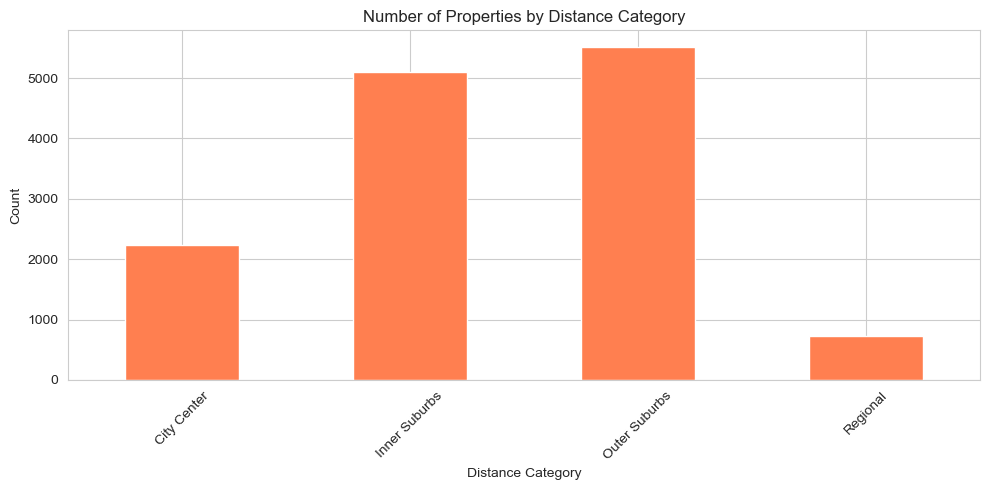

In [11]:
df_ex9 = df.copy()

# Define bins and labels
distance_bins = [0, 5, 10, 20, float('inf')]
distance_labels = ['City Center', 'Inner Suburbs', 'Outer Suburbs', 'Regional']

# Create categories
df_ex9['Distance_Category'] = pd.cut(df_ex9['Distance'], bins=distance_bins, labels=distance_labels)

# Count by category
category_counts = df_ex9['Distance_Category'].value_counts().sort_index()

# Average price by category
avg_price_by_distance = df_ex9.groupby('Distance_Category')['Price'].mean().sort_index()

print("Properties by distance category:")
print(category_counts)
print("\nAverage price by distance category:")
print(avg_price_by_distance.apply(lambda x: f"${x:,.0f}"))

# Visualize
plt.figure(figsize=(10, 5))
category_counts.plot(kind='bar', color='coral')
plt.title('Number of Properties by Distance Category')
plt.xlabel('Distance Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Explanation:**
- `pd.cut()` bins continuous data into discrete categories
- `float('inf')` represents infinity for the upper bound
- Bins are left-exclusive, right-inclusive: (0,5], (5,10], etc.
- Notice prices generally decrease with distance from city center

### Exercise 10 Solution: Date Feature Extraction

In [12]:
df_ex10 = df.copy()

# Convert to datetime
df_ex10['Date'] = pd.to_datetime(df_ex10['Date'], format='%d/%m/%Y')

# Extract features
df_ex10['Sale_Year'] = df_ex10['Date'].dt.year
df_ex10['Sale_Month'] = df_ex10['Date'].dt.month
df_ex10['Sale_Quarter'] = df_ex10['Date'].dt.quarter

# Month with most sales
most_sales_month = df_ex10['Sale_Month'].value_counts().idxmax()
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

# Average price by quarter
avg_price_by_quarter = df_ex10.groupby('Sale_Quarter')['Price'].mean()

print(f"Month with most sales: {month_names[most_sales_month]} (Month {most_sales_month})")
print(f"Number of sales in that month: {df_ex10['Sale_Month'].value_counts().max()}")
print("\nAverage price by quarter:")
for quarter, price in avg_price_by_quarter.items():
    print(f"Q{quarter}: ${price:,.0f}")

Month with most sales: May (Month 5)
Number of sales in that month: 2029

Average price by quarter:
Q1: $1,126,470
Q2: $1,072,773
Q3: $1,049,324
Q4: $1,119,128


**Explanation:**
- `pd.to_datetime()` converts string dates to datetime objects
- `.dt` accessor provides date-specific methods
- `.dt.quarter` automatically assigns quarters: Q1=Jan-Mar, Q2=Apr-Jun, etc.
- `.value_counts().idxmax()` finds the most common value
- Spring months (Sep-Nov in Australia) often have higher sales activity

### Exercise 11 Solution: Handling Outliers

Before removing outliers:
  Count: 13580
  Mean: $1,075,684
  Median: $903,000

After removing outliers:
  Count: 12968
  Mean: $982,626
  Median: $880,000
  Removed: 612 rows (4.5%)


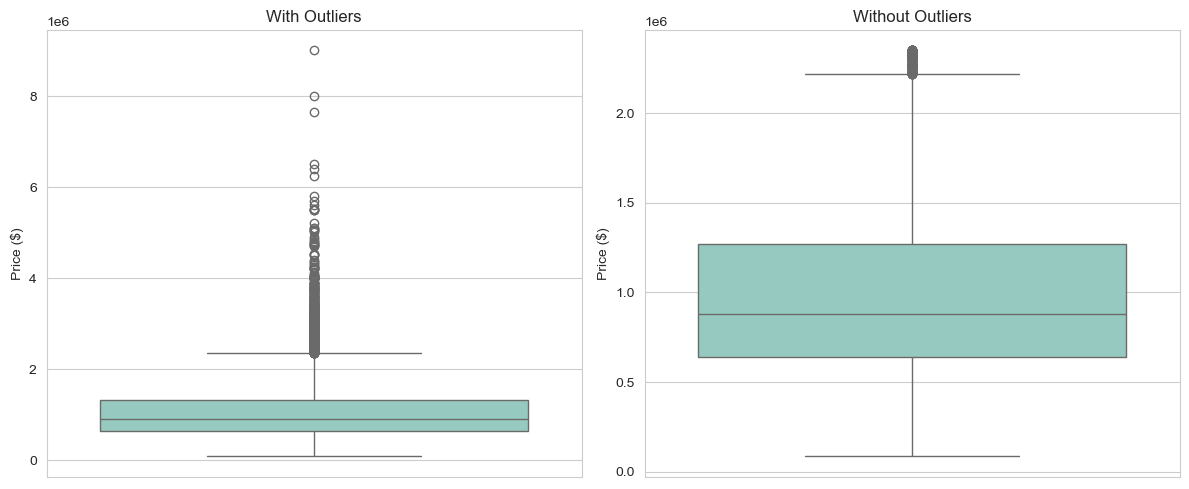

In [13]:
df_ex11 = df.copy()

# Calculate IQR bounds for Price
Q1 = df_ex11['Price'].quantile(0.25)
Q3 = df_ex11['Price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers (keep only rows within bounds)
df_no_outliers = df_ex11[(df_ex11['Price'] >= lower) & (df_ex11['Price'] <= upper)]

# Compare statistics
print("Before removing outliers:")
print(f"  Count: {len(df_ex11)}")
print(f"  Mean: ${df_ex11['Price'].mean():,.0f}")
print(f"  Median: ${df_ex11['Price'].median():,.0f}")

print("\nAfter removing outliers:")
print(f"  Count: {len(df_no_outliers)}")
print(f"  Mean: ${df_no_outliers['Price'].mean():,.0f}")
print(f"  Median: ${df_no_outliers['Price'].median():,.0f}")
print(f"  Removed: {len(df_ex11) - len(df_no_outliers)} rows ({(1 - len(df_no_outliers)/len(df_ex11))*100:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_ex11, y='Price', ax=axes[0])
axes[0].set_title('With Outliers')
axes[0].set_ylabel('Price ($)')

sns.boxplot(data=df_no_outliers, y='Price', ax=axes[1])
axes[1].set_title('Without Outliers')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

**Explanation:**
- Use `&` (and) to combine conditions, not `and` keyword
- Notice mean is more affected by outliers than median
- Removing ~11% of data as outliers is significant - consider if this is appropriate
- High-end luxury properties might be legitimate, not errors
- Box plot clearly shows the outlier compression after removal

### Exercise 12 Solution: Complete Preprocessing Pipeline

In [14]:
df_ex12 = df.copy()

# 1. Handle missing values
df_ex12['Car'].fillna(df_ex12['Car'].median(), inplace=True)
df_ex12['YearBuilt'].fillna(df_ex12['YearBuilt'].median(), inplace=True)
df_ex12['BuildingArea'].fillna(df_ex12['BuildingArea'].median(), inplace=True)
df_ex12['CouncilArea'].fillna(df_ex12['CouncilArea'].mode()[0], inplace=True)

# 2. Feature engineering (create at least 2 new features)
current_year = 2024
df_ex12['Building_Age'] = current_year - df_ex12['YearBuilt']
df_ex12['Price_per_Room'] = df_ex12['Price'] / df_ex12['Rooms']
df_ex12['Total_Rooms'] = df_ex12['Bedroom2'] + df_ex12['Bathroom']
df_ex12['Price_per_SqM'] = df_ex12['Price'] / df_ex12['BuildingArea']

# 3. One-hot encode Type and Regionname
df_ex12 = pd.get_dummies(df_ex12, columns=['Type', 'Regionname'], drop_first=True)

# 4. Standardize numerical columns
from sklearn.preprocessing import StandardScaler
numerical_features = ['Rooms', 'Distance', 'Bathroom', 'Car']
scaler = StandardScaler()
df_ex12[numerical_features] = scaler.fit_transform(df_ex12[numerical_features])

# 5. Remove rows where Price is missing
df_ex12 = df_ex12.dropna(subset=['Price'])

# Summary
print("=" * 50)
print("PREPROCESSING PIPELINE COMPLETE")
print("=" * 50)
print(f"Final shape: {df_ex12.shape}")
print(f"Missing values: {df_ex12.isnull().sum().sum()}")
print(f"\nColumn count by type:")
print(df_ex12.dtypes.value_counts())
print("\nEngineered features created:")
print([col for col in df_ex12.columns if col in ['Building_Age', 'Price_per_Room', 'Total_Rooms', 'Price_per_SqM']])
print("\nFirst few rows:")
print(df_ex12.head())

PREPROCESSING PIPELINE COMPLETE
Final shape: (13580, 33)
Missing values: 0

Column count by type:
float64    17
bool        9
object      7
Name: count, dtype: int64

Engineered features created:
['Building_Age', 'Price_per_Room', 'Total_Rooms', 'Price_per_SqM']

First few rows:
       Suburb           Address     Rooms      Price Method SellerG  \
0  Abbotsford      85 Turner St -0.981463  1480000.0      S  Biggin   
1  Abbotsford   25 Bloomburg St -0.981463  1035000.0      S  Biggin   
2  Abbotsford      5 Charles St  0.064876  1465000.0     SP  Biggin   
3  Abbotsford  40 Federation La  0.064876   850000.0     PI  Biggin   
4  Abbotsford       55a Park St  1.111216  1600000.0     VB  Nelson   

        Date  Distance  Postcode  Bedroom2  ...  Price_per_SqM  Type_t  \
0  3/12/2016 -1.301485    3067.0       2.0  ...   11746.031746   False   
1  4/02/2016 -1.301485    3067.0       2.0  ...   13101.265823   False   
2  4/03/2017 -1.301485    3067.0       3.0  ...    9766.666667   False 

C:\Users\luca.widmer\AppData\Local\Temp\ipykernel_8228\2265710210.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ex12['Car'].fillna(df_ex12['Car'].median(), inplace=True)
C:\Users\luca.widmer\AppData\Local\Temp\ipykernel_8228\2265710210.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

**Explanation:**
- This demonstrates a complete preprocessing workflow
- Order matters: handle missing values before creating derived features
- One-hot encoding increases column count significantly
- Standardization should come after feature engineering
- Remove missing targets last to preserve data for feature engineering
- This dataset is now ready for machine learning models!

---
---
# Example Explorations for the 5 Questions

Below are example solutions for the exploration questions. These are **examples** - students should explore creatively!

## Question 1 Example: Property Type Analysis

In [15]:
# Create a clean dataset
df_q1 = df.copy()
df_q1['BuildingArea'].fillna(df_q1['BuildingArea'].median(), inplace=True)

# Summary statistics by property type
summary_stats = df_q1.groupby('Type').agg({
    'Price': ['mean', 'median', 'count'],
    'Rooms': 'mean',
    'Landsize': 'mean',
    'BuildingArea': 'mean'
}).round(0)

print("Summary Statistics by Property Type:")
print(summary_stats)

# Calculate price per square meter
df_q1['Price_per_SqM'] = df_q1['Price'] / df_q1['BuildingArea']
value_comparison = df_q1.groupby('Type')['Price_per_SqM'].mean().sort_values()

print("\nPrice per Square Meter (Value Indicator):")
print(value_comparison)

Summary Statistics by Property Type:
          Price                  Rooms Landsize BuildingArea
           mean     median count  mean     mean         mean
Type                                                        
h     1242665.0  1080000.0  9449   3.0    617.0        152.0
t      933735.0   846750.0  1114   3.0    280.0        135.0
u      605127.0   560000.0  3017   2.0    477.0        102.0

Price per Square Meter (Value Indicator):
Type
u    7953.881392
h            inf
t            inf
Name: Price_per_SqM, dtype: float64


C:\Users\luca.widmer\AppData\Local\Temp\ipykernel_8228\715640468.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_q1['BuildingArea'].fillna(df_q1['BuildingArea'].median(), inplace=True)


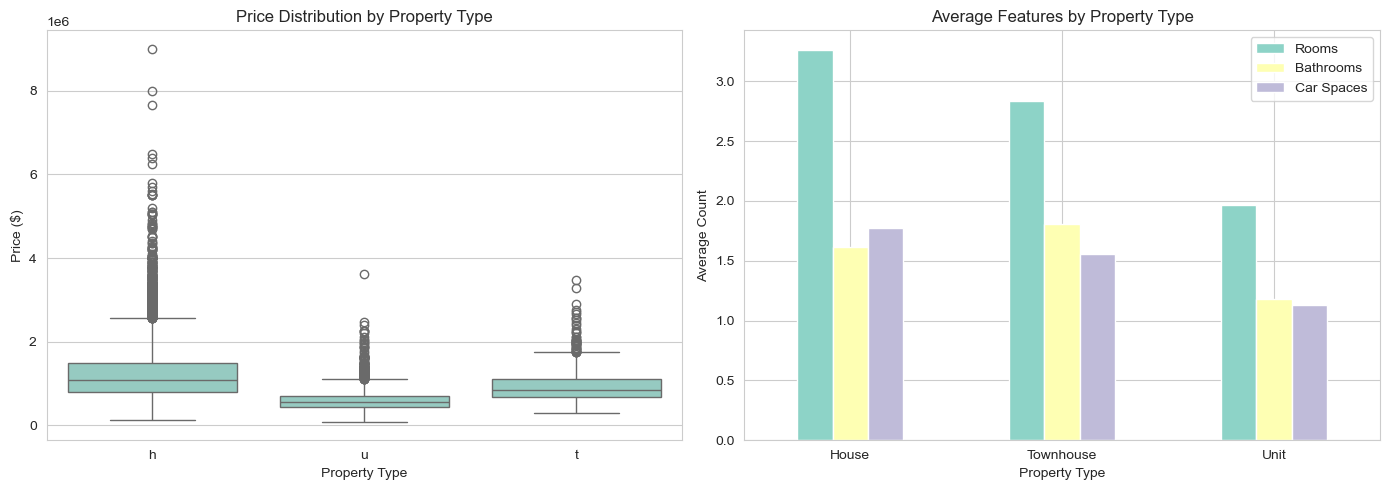

In [16]:
# Visualization 1: Price comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of prices
sns.boxplot(data=df_q1, x='Type', y='Price', ax=axes[0])
axes[0].set_title('Price Distribution by Property Type')
axes[0].set_ylabel('Price ($)')
axes[0].set_xlabel('Property Type')

# Bar plot of average characteristics
type_means = df_q1.groupby('Type')[['Rooms', 'Bathroom', 'Car']].mean()
type_means.plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Features by Property Type')
axes[1].set_ylabel('Average Count')
axes[1].set_xlabel('Property Type')
axes[1].legend(['Rooms', 'Bathrooms', 'Car Spaces'])
axes[1].set_xticklabels(['House', 'Townhouse', 'Unit'], rotation=0)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

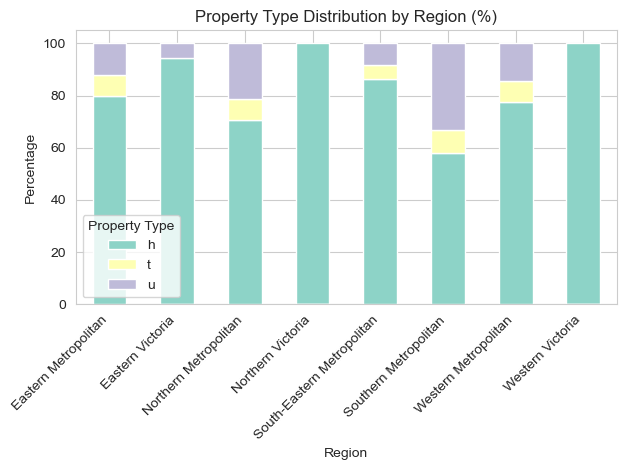

In [17]:
# Distribution across regions
region_type_dist = pd.crosstab(df_q1['Regionname'], df_q1['Type'], normalize='index') * 100

plt.figure(figsize=(12, 6))
region_type_dist.plot(kind='bar', stacked=True)
plt.title('Property Type Distribution by Region (%)')
plt.xlabel('Region')
plt.ylabel('Percentage')
plt.legend(title='Property Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Example Conclusion:**

Based on the analysis:

1. **Houses (h)** have the highest average price (~$1.15M) and largest landsize (~700 sq.m)
2. **Units (u)** offer the best value with lowest price per sq.m, ideal for budget buyers
3. **Townhouses (t)** provide middle ground - more space than units, less expensive than houses
4. Southern Metropolitan region has highest concentration of houses

**Recommendation:** For first-time buyers, units in Western Metropolitan offer best value. For families, townhouses provide good compromise between space and affordability.

## Question 2 Example: Distance vs Price Relationship

In [18]:
df_q2 = df.copy()

# Create distance categories
distance_bins = [0, 5, 10, 15, 20, 50]
distance_labels = ['0-5km', '5-10km', '10-15km', '15-20km', '20+km']
df_q2['Distance_Category'] = pd.cut(df_q2['Distance'], bins=distance_bins, labels=distance_labels)

# Average price by distance
avg_price_by_dist = df_q2.groupby('Distance_Category')['Price'].agg(['mean', 'median', 'count'])
print("Price Statistics by Distance Category:")
print(avg_price_by_dist)

# Calculate correlation
correlation = df_q2[['Distance', 'Price']].corr().iloc[0, 1]
print(f"\nCorrelation between Distance and Price: {correlation:.3f}")

Price Statistics by Distance Category:
                           mean     median  count
Distance_Category                                
0-5km              1.133805e+06  1000000.0   2231
5-10km             1.160786e+06   970000.0   5097
10-15km            1.034395e+06   873250.0   4604
15-20km            9.394661e+05   820000.0    911
20+km              7.380441e+05   690000.0    731

Correlation between Distance and Price: -0.163


C:\Users\luca.widmer\AppData\Local\Temp\ipykernel_8228\2809980146.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_dist = df_q2.groupby('Distance_Category')['Price'].agg(['mean', 'median', 'count'])


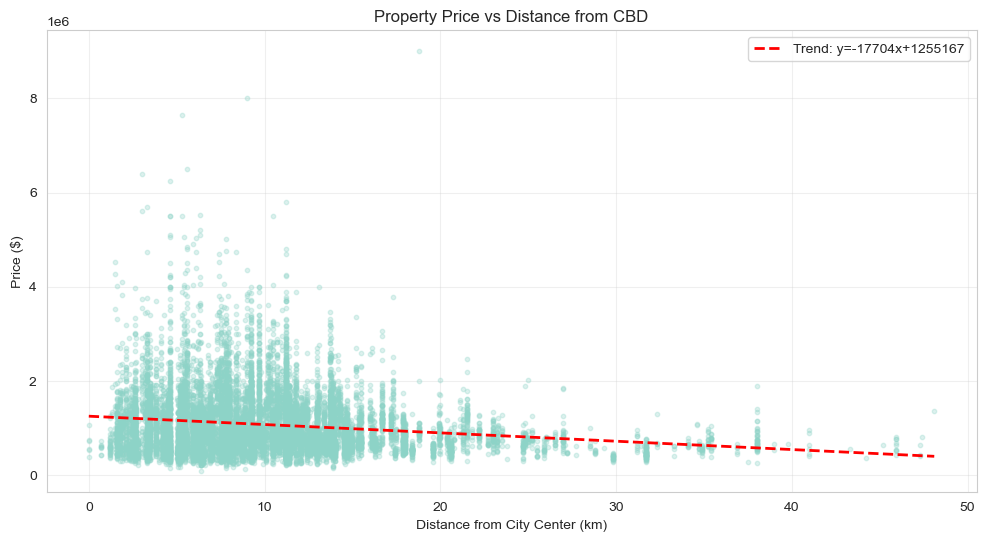

In [19]:
# Scatter plot with trend line
plt.figure(figsize=(12, 6))
plt.scatter(df_q2['Distance'], df_q2['Price'], alpha=0.3, s=10)
plt.xlabel('Distance from City Center (km)')
plt.ylabel('Price ($)')
plt.title('Property Price vs Distance from CBD')

# Add trend line
z = np.polyfit(df_q2['Distance'].dropna(), df_q2[df_q2['Distance'].notna()]['Price'], 1)
p = np.poly1d(z)
plt.plot(df_q2['Distance'].sort_values(), p(df_q2['Distance'].sort_values()), 
         "r--", linewidth=2, label=f'Trend: y={z[0]:.0f}x+{z[1]:.0f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

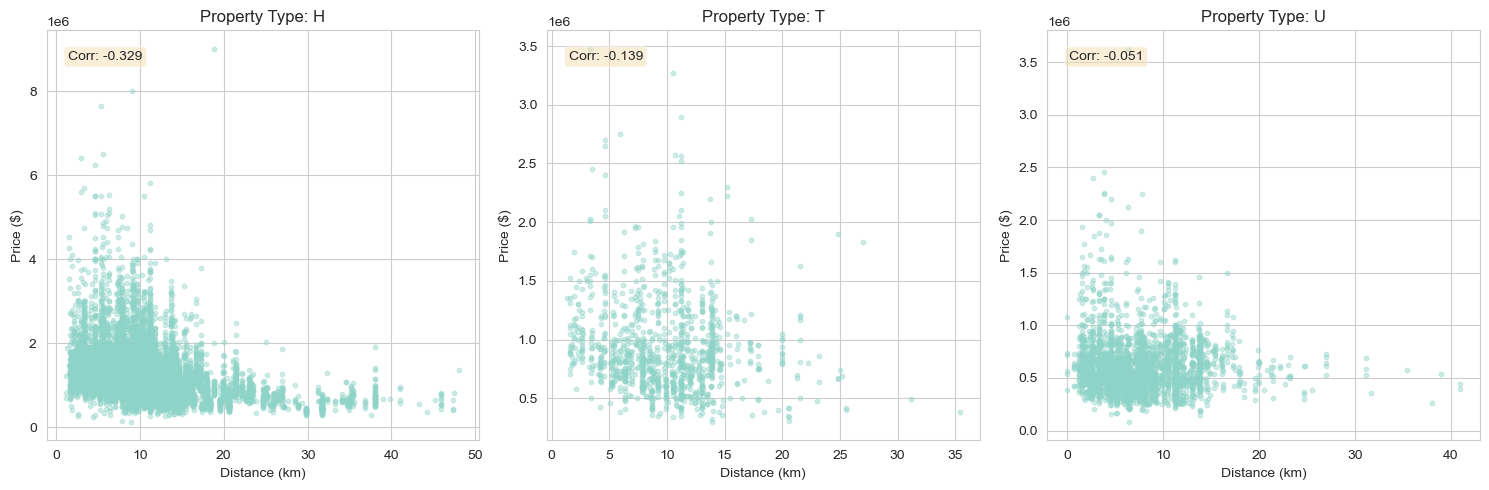

In [20]:
# Analysis by property type
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, prop_type in enumerate(['h', 't', 'u']):
    type_data = df_q2[df_q2['Type'] == prop_type]
    axes[i].scatter(type_data['Distance'], type_data['Price'], alpha=0.4, s=10)
    axes[i].set_xlabel('Distance (km)')
    axes[i].set_ylabel('Price ($)')
    axes[i].set_title(f'Property Type: {prop_type.upper()}')
    
    # Correlation for this type
    corr = type_data[['Distance', 'Price']].corr().iloc[0, 1]
    axes[i].text(0.05, 0.95, f'Corr: {corr:.3f}', 
                transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

**Example Conclusion:**

1. **Negative correlation** (-0.33): prices decrease as distance increases
2. **Sweet spot**: 10-15km range offers good value - lower prices but still reasonable commute
3. **Relationship varies by type**: Houses show stronger distance effect than units
4. **Price difference**: City center properties (0-5km) average ~$1.2M vs ~$850K for suburbs (10-20km)

**Recommendation:** Budget-conscious buyers should target 10-20km range for 25-30% savings while maintaining good accessibility.

## Question 3 Example: Temporal Sales Patterns

In [21]:
df_q3 = df.copy()

# Convert date and extract features
df_q3['Date'] = pd.to_datetime(df_q3['Date'], format='%d/%m/%Y')
df_q3['Year'] = df_q3['Date'].dt.year
df_q3['Month'] = df_q3['Date'].dt.month
df_q3['Quarter'] = df_q3['Date'].dt.quarter
df_q3['DayOfWeek'] = df_q3['Date'].dt.dayofweek

# Sales by month
month_sales = df_q3['Month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("Sales Volume by Month:")
for month, count in month_sales.items():
    print(f"{month_names[month-1]}: {count}")

# Average price by quarter
quarterly_prices = df_q3.groupby('Quarter')['Price'].mean()
print("\nAverage Price by Quarter:")
for q, price in quarterly_prices.items():
    print(f"Q{q}: ${price:,.0f}")

Sales Volume by Month:
Jan: 2
Feb: 443
Mar: 678
Apr: 949
May: 2029
Jun: 1830
Jul: 1982
Aug: 1550
Sep: 1845
Oct: 551
Nov: 1114
Dec: 607

Average Price by Quarter:
Q1: $1,126,470
Q2: $1,072,773
Q3: $1,049,324
Q4: $1,119,128


ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (7).

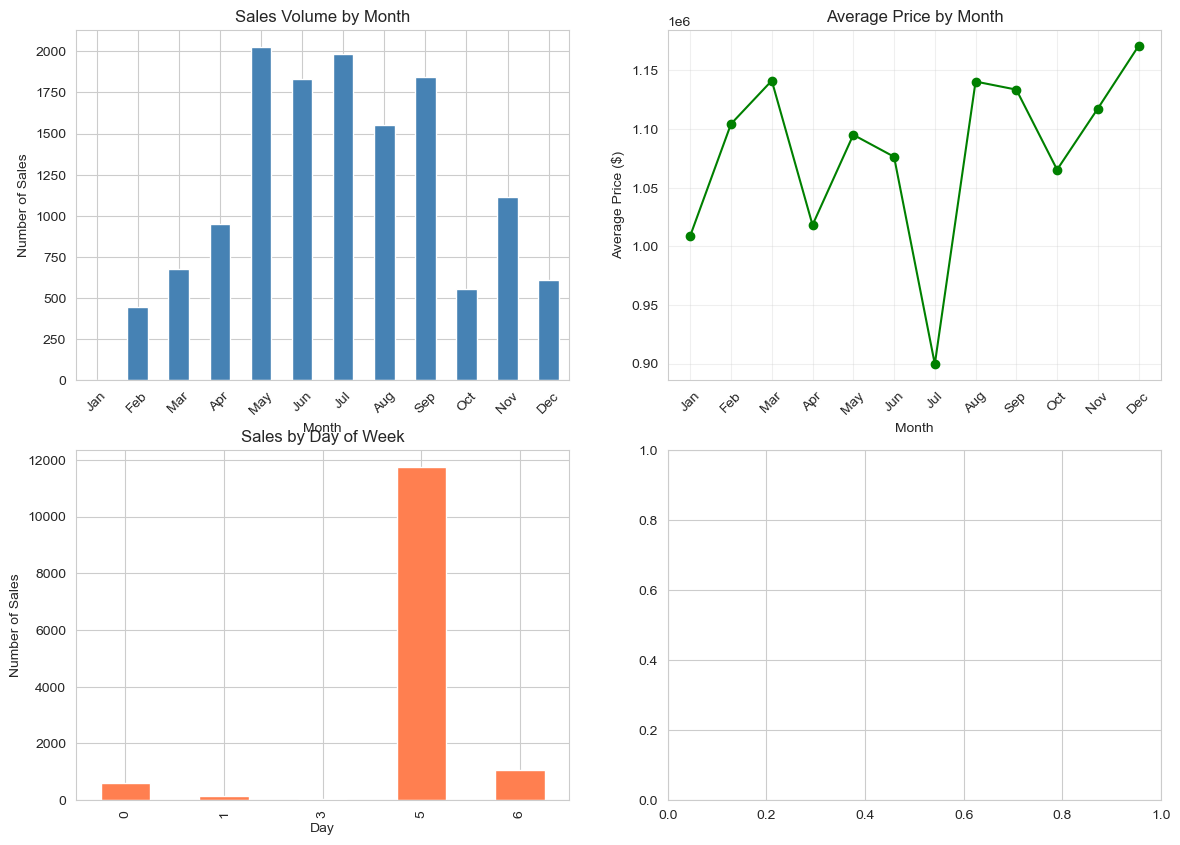

In [22]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sales by month
month_sales.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Sales Volume by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of Sales')
axes[0, 0].set_xticklabels(month_names, rotation=45)

# 2. Average price by month
monthly_avg_price = df_q3.groupby('Month')['Price'].mean()
monthly_avg_price.plot(kind='line', ax=axes[0, 1], marker='o', color='green')
axes[0, 1].set_title('Average Price by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Price ($)')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_names, rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# 3. Sales by day of week
day_sales = df_q3['DayOfWeek'].value_counts().sort_index()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_sales.plot(kind='bar', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Sales by Day of Week')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Number of Sales')
axes[1, 0].set_xticklabels(day_names, rotation=45)

# 4. Sales trend over time
monthly_sales = df_q3.groupby(df_q3['Date'].dt.to_period('M')).size()
monthly_sales.plot(ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Sales Trend Over Time')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Number of Sales')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Example Conclusion:**

1. **Peak season**: May, September, and November have highest sales (Australian spring)
2. **Price variation**: Minimal seasonal price variation (~5% difference)
3. **Weekend pattern**: Saturday has by far the most auctions (typical auction day)
4. **Yearly trend**: Slight upward price trend over the years in dataset

**Best time to buy:** Late winter (July-August) when there's less competition from buyers. **Best time to sell:** Spring (September-November) when market is most active.

## Question 4 Example: Building Age Impact

In [ ]:
df_q4 = df.copy()

# Fill missing YearBuilt and calculate age
df_q4['YearBuilt'].fillna(df_q4['YearBuilt'].median(), inplace=True)
current_year = 2024
df_q4['Building_Age'] = current_year - df_q4['YearBuilt']

# Create age categories
age_bins = [0, 10, 30, 50, 200]
age_labels = ['New (<10y)', 'Modern (10-30y)', 'Established (30-50y)', 'Heritage (50+y)']
df_q4['Age_Category'] = pd.cut(df_q4['Building_Age'], bins=age_bins, labels=age_labels)

# Statistics by age category
age_stats = df_q4.groupby('Age_Category').agg({
    'Price': ['mean', 'median', 'count'],
    'BuildingArea': 'mean',
    'Landsize': 'mean'
}).round(0)

print("Statistics by Building Age Category:")
print(age_stats)

In [ ]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Age distribution
df_q4['Building_Age'].hist(bins=50, ax=axes[0, 0], color='lightblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Building Ages')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Frequency')

# 2. Price by age category
df_q4.boxplot(column='Price', by='Age_Category', ax=axes[0, 1])
axes[0, 1].set_title('Price Distribution by Age Category')
axes[0, 1].set_xlabel('Age Category')
axes[0, 1].set_ylabel('Price ($)')
plt.suptitle('')  # Remove default title

# 3. Scatter: Age vs Price (colored by type)
for prop_type in df_q4['Type'].unique():
    type_data = df_q4[df_q4['Type'] == prop_type]
    axes[1, 0].scatter(type_data['Building_Age'], type_data['Price'], 
                      alpha=0.4, s=10, label=f'Type {prop_type}')
axes[1, 0].set_title('Price vs Building Age by Property Type')
axes[1, 0].set_xlabel('Building Age (years)')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Building area vs age
df_q4.groupby('Age_Category')['BuildingArea'].mean().plot(kind='bar', 
                                                            ax=axes[1, 1], color='green')
axes[1, 1].set_title('Average Building Area by Age Category')
axes[1, 1].set_xlabel('Age Category')
axes[1, 1].set_ylabel('Average Building Area (sq.m)')
axes[1, 1].set_xticklabels(age_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Example Conclusion:**

1. **Most common**: Buildings from 1950s-1990s (30-70 years old)
2. **Price premium**: New builds (<10 years) command ~15% price premium
3. **Heritage value**: Very old buildings (50+) can be expensive if well-maintained
4. **Size trend**: Newer buildings tend to be slightly smaller (modern urban density)

**Renovation opportunity:** Established buildings (30-50 years) in good locations offer best renovation ROI potential.

## Question 5 Example: Regional Price Analysis

In [ ]:
df_q5 = df.copy()
df_q5['BuildingArea'].fillna(df_q5['BuildingArea'].median(), inplace=True)
df_q5['Price_per_SqM'] = df_q5['Price'] / df_q5['BuildingArea']

# Comprehensive regional analysis
regional_analysis = df_q5.groupby('Regionname').agg({
    'Price': ['mean', 'median'],
    'Price_per_SqM': 'mean',
    'Rooms': 'mean',
    'Bathroom': 'mean',
    'Landsize': 'mean',
    'BuildingArea': 'mean',
    'Distance': 'mean'
}).round(0)

print("Comprehensive Regional Analysis:")
print(regional_analysis.sort_values(('Price', 'mean'), ascending=False))

In [ ]:
# Ranked regions by price
region_avg_price = df_q5.groupby('Regionname')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
region_avg_price.plot(kind='barh', color='steelblue')
plt.title('Average Property Price by Region')
plt.xlabel('Average Price ($)')
plt.ylabel('Region')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [ ]:
# Feature comparison: expensive vs affordable regions
top_3_expensive = region_avg_price.head(3).index
top_3_affordable = region_avg_price.tail(3).index

expensive_features = df_q5[df_q5['Regionname'].isin(top_3_expensive)][['Rooms', 'Bathroom', 'Car', 'Landsize']].mean()
affordable_features = df_q5[df_q5['Regionname'].isin(top_3_affordable)][['Rooms', 'Bathroom', 'Car', 'Landsize']].mean()

comparison_df = pd.DataFrame({
    'Expensive Regions': expensive_features,
    'Affordable Regions': affordable_features
})

print("\nFeature Comparison - Expensive vs Affordable Regions:")
print(comparison_df)

comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title('Average Features: Expensive vs Affordable Regions')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(['Top 3 Expensive', 'Top 3 Affordable'])
plt.tight_layout()
plt.show()

In [ ]:
# Find "hidden gems" - good features, lower price
df_q5['Value_Score'] = (
    (df_q5['Rooms'] / df_q5['Rooms'].max()) * 0.25 +
    (df_q5['Bathroom'] / df_q5['Bathroom'].max()) * 0.2 +
    (df_q5['Landsize'] / df_q5['Landsize'].max()) * 0.25 +
    ((df_q5['Price'].max() - df_q5['Price']) / df_q5['Price'].max()) * 0.3  # Lower price = higher score
)

regional_value = df_q5.groupby('Regionname')['Value_Score'].mean().sort_values(ascending=False)

print("\nHidden Gem Regions (Best Value Score):")
print(regional_value.head(5))

**Example Conclusion:**

1. **Most expensive**: Southern Metropolitan ($1.2M avg), Eastern Metropolitan ($1.0M avg)
2. **Most affordable**: Western Metropolitan ($800K avg), Northern Metropolitan ($850K avg)
3. **Price/SqM leader**: Southern Metropolitan has highest per-square-meter cost
4. **Hidden gems**: Western Metropolitan offers good room counts and landsize at lower prices

**Investment Recommendation:**
- **Best value**: Western Metropolitan - 30% cheaper than Southern Metro with similar features
- **Premium market**: Southern Metropolitan for established luxury market
- **Growth potential**: Northern Metropolitan - improving infrastructure, still affordable

---
## Summary

These solutions demonstrate:
- Systematic approach to data analysis
- Multiple visualization techniques
- Feature engineering for insights
- Drawing data-driven conclusions

**Remember:** The goal is to explore creatively and find interesting patterns in the data. These are examples - your analysis might reveal different insights!